# Advanced Elution Models

## Preliminary Decomposition

Advanced models are usually harder to fit compared to EGH model which is the default. Therefore, we make it a rule to first decompose using EGH model and proceed to advanced models based on the first result. This rule is formalized in a coding rule as follows:

1. you have to use ssd.quick_decomposition() as the first step to make a decomosition object,
2. then using the result, you can proceed to decomosition.optimize_with_model().

This second step provides advanced models, which are eihther SDM or EDM.

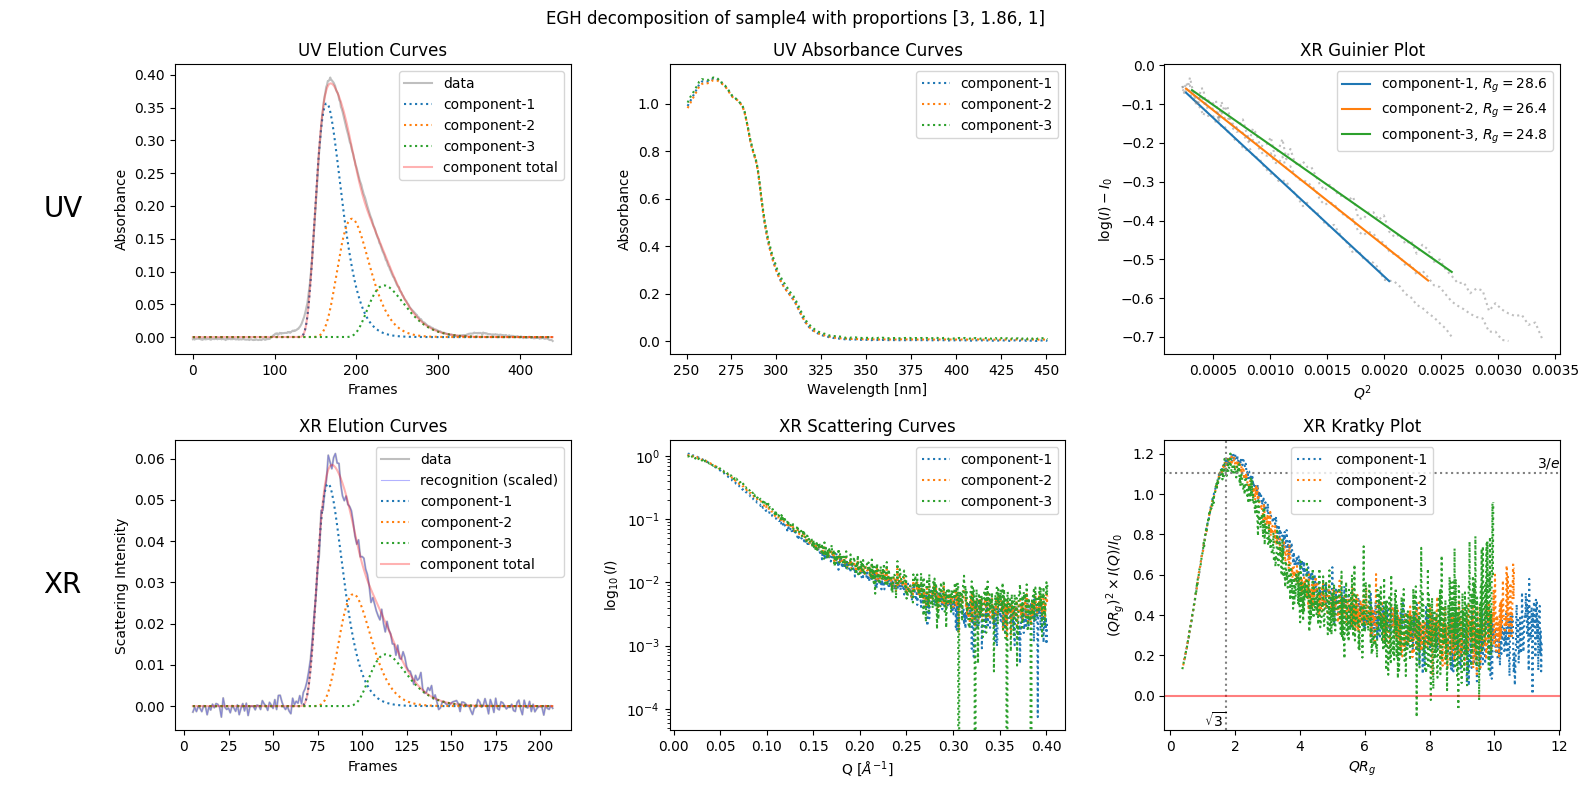

In [1]:
from molass import get_version
assert get_version() >= '0.7.4', "This tutorial requires molass version 0.7.4 or higher."
from molass_legacy import get_version
assert get_version() >= '0.4.0', "This tutorial requires molass_legacy version 0.4.0 or higher."
from molass_data import get_version
assert get_version() >= '0.3.0', "This tutorial requires molass_data version 0.3.0 or higher."

from molass_data import SAMPLE4
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE4)
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
decomposition = corrected_ssd.quick_decomposition(proportions=[3., 1.85714286, 1.])
decomposition.plot_components(title="EGH decomposition of sample4 with proportions [3, 1.86, 1]");

## Stochastic Models
### Stochastic Dispersive Model

C:\Users\takahashi\AppData\Local\Temp\ipykernel_71072\1935981112.py:1: DeprecationWarning: optimize_with_model is deprecated; use upgrade() instead.
  sdm_decomposition = decomposition.optimize_with_model('SDM', debug=False)


C:\Users\takahashi\GitHub\molass-library\molass\SEC\Models\SdmOptimizer.py:364: OptimizeWarning: Initial guess is not within the specified bounds
  r = minimize(objective_function, start, bounds=bounds, method=method,


Adjusted poresize from 109.998 to 112.015


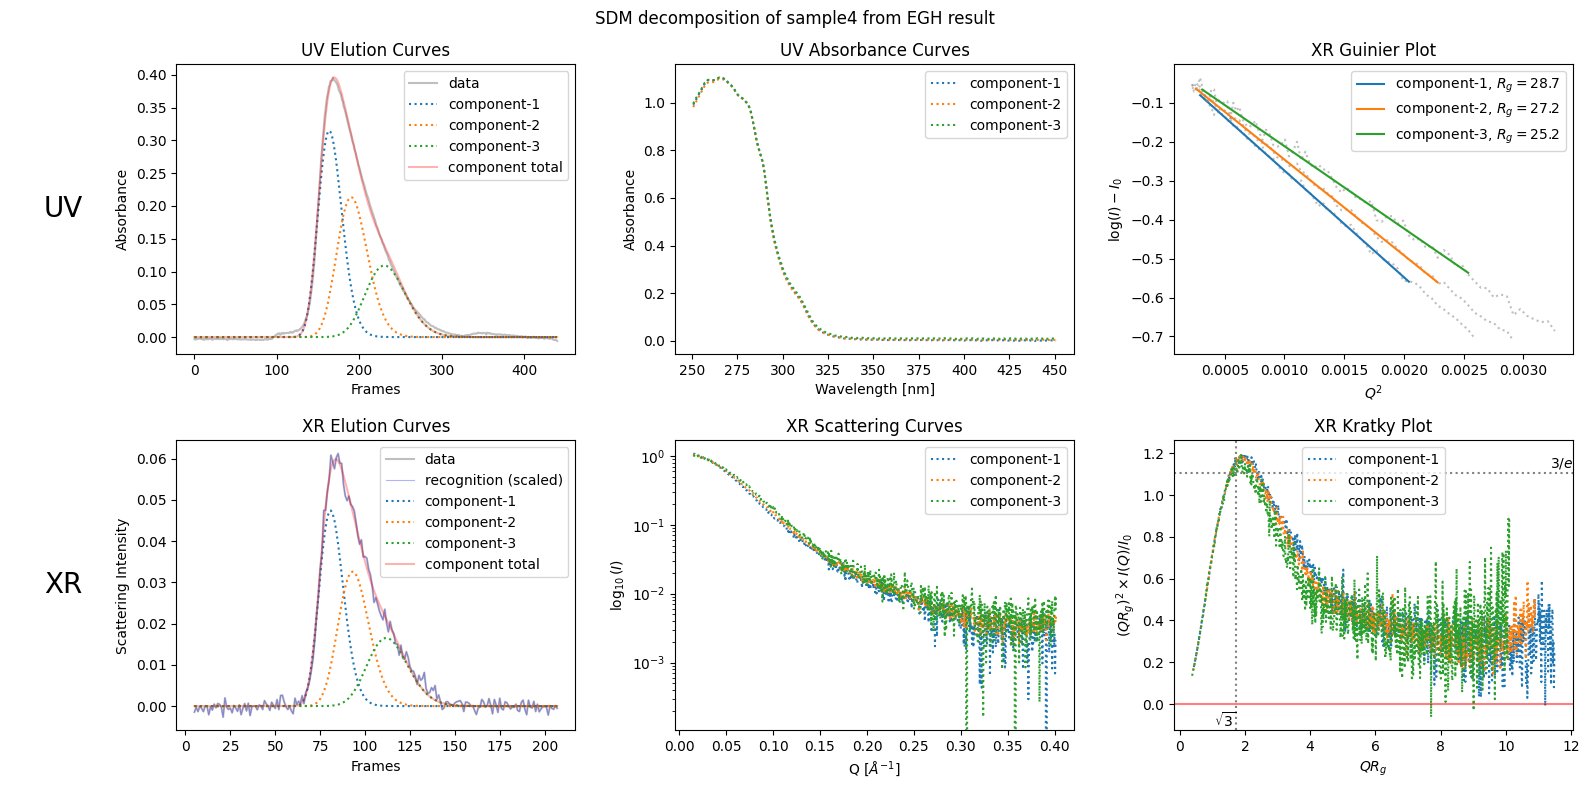

In [2]:
sdm_decomposition = decomposition.optimize_with_model('SDM', debug=False)
sdm_decomposition.plot_components(title="SDM decomposition of sample4 from EGH result");

## Kinetic Models

### Equilibrium Dispersive Model

C:\Users\takahashi\AppData\Local\Temp\ipykernel_71072\204666909.py:1: DeprecationWarning: optimize_with_model is deprecated; use upgrade() instead.
  edm_decomposition = decomposition.optimize_with_model('EDM', debug=False)
C:\Users\takahashi\GitHub\molass-legacy\molass_legacy\SecTheory\Edm.py:186: RuntimeWarning: overflow encountered in exp
  numer = U*(expB - 1)*np.exp(-V)


guess_init_params: M2= 67.63656710574234
area ratio= 0.3604985162978555
guess_init_params: M2= 93.16188659924399
area ratio= 0.35523668020940713


guess_init_params: M2= 137.63219802754892
area ratio= 0.3521426147302077


C:\Users\takahashi\GitHub\molass-legacy\molass_legacy\SecTheory\Edm.py:159: RuntimeWarning: overflow encountered in exp
  ret_y = cinj * _tau_inj * np.exp(-_V) / (2*_W)
C:\Users\takahashi\GitHub\molass-legacy\molass_legacy\SecTheory\Edm.py:178: RuntimeWarning: divide by zero encountered in scalar divide
  U = 2/(lam*Pe)


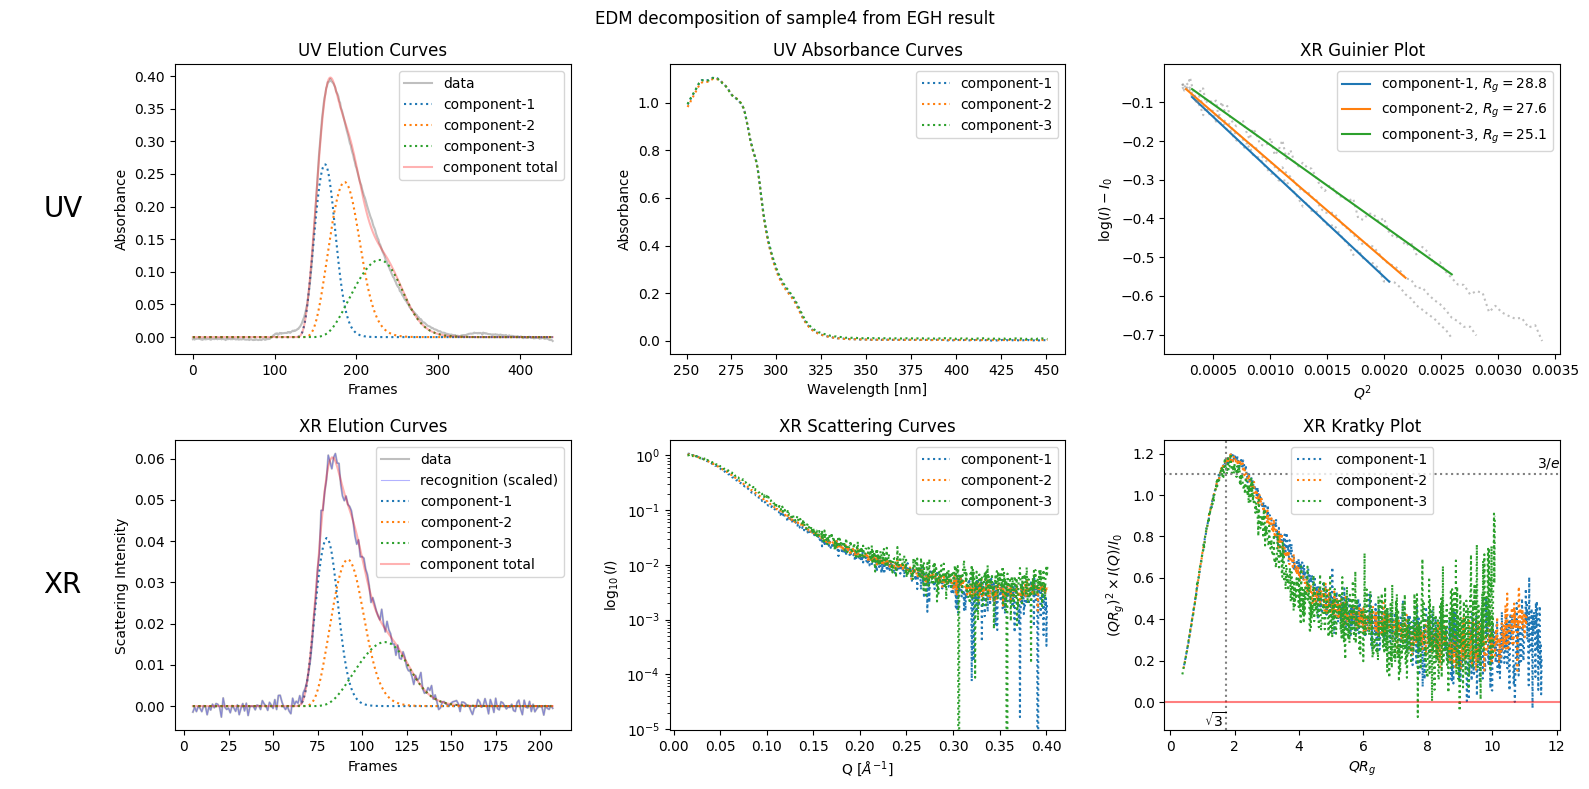

In [3]:
edm_decomposition = decomposition.optimize_with_model('EDM', debug=False)
edm_decomposition.plot_components(title="EDM decomposition of sample4 from EGH result");